# AnimeRadar EDA & Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('combined_clean.csv')
df.head()

,title,score,members,favorites,episodes,status,genres,season,year
0,Jujutsu Kaisen,8.51,2983273,95527,24,Finished Airing,"['Action', 'Award Winning', 'Supernatural']",fall,2020
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,1756871,13487,1,Finished Airing,"['Action', 'Supernatural']",fall,2020
2,Haikyuu!! To the Top Part 2,8.56,918587,6479,12,Finished Airing,['Sports'],fall,2020
3,Tonikaku Kawaii,7.84,829699,10466,12,Finished Airing,"['Comedy', 'Romance']",fall,2020
4,Dungeon ni Deai wo Motomeru no wa Machigatteir...,7.46,674005,1966,12,Finished Airing,"['Action', 'Adventure', 'Fantasy']",fall,2020


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      500 non-null    object 
 1   score      500 non-null    float64
 2   members    500 non-null    int64  
 3   favorites  500 non-null    int64  
 4   episodes   500 non-null    int64  
 5   status     500 non-null    object 
 6   genres     500 non-null    object 
 7   season     500 non-null    object 
 8   year       500 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 35.3+ KB


In [4]:
df.describe()

,score,members,favorites,episodes,year
count,500.000000,5.000000e+02,500.000000,500.0000,500.00000
mean,7.500580,3.972140e+05,4489.992000,12.2940,2022.00000
std,0.722593,3.382377e+05,8792.496646,6.0346,1.41563
min,5.240000,6.123300e+04,58.000000,1.0000,2020.00000
25%,7.037500,1.878295e+05,829.500000,12.0000,2021.00000
50%,7.525000,2.798010e+05,1734.000000,12.0000,2022.00000
75%,8.060000,4.846555e+05,4285.500000,13.0000,2023.00000
max,9.280000,2.983273e+06,95527.000000,67.0000,2024.00000


In [5]:
print(df['season'].value_counts())

season
fall      125
spring    125
summer    125
winter    125
Name: count, dtype: int64


In [6]:
print(df['year'].value_counts().sort_index())

year
2020    100
2021    100
2022    100
2023    100
2024    100
Name: count, dtype: int64


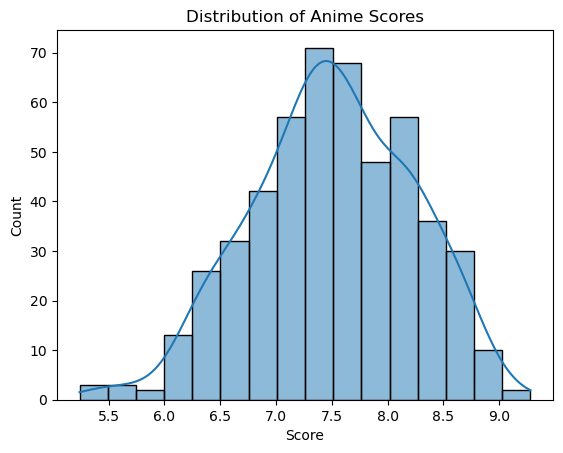

In [7]:
sns.histplot(df['score'], kde=True)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.show()

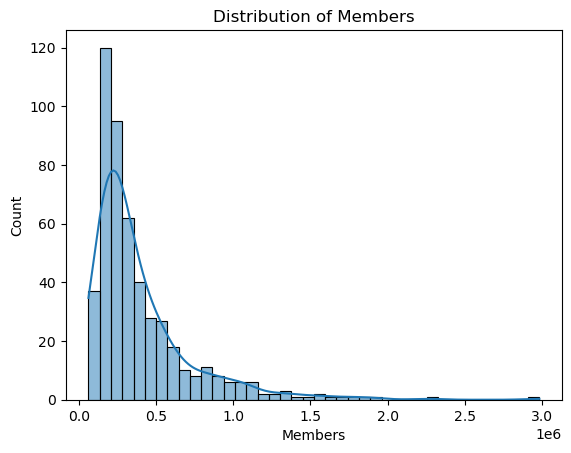

In [8]:
sns.histplot(df['members'], kde=True)
plt.title('Distribution of Members')
plt.xlabel('Members')
plt.show()

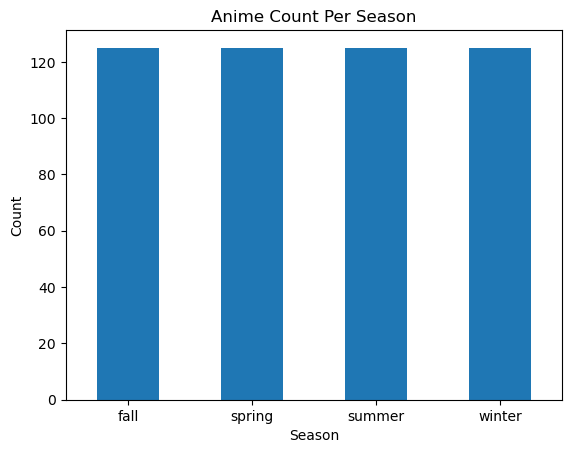

In [9]:
df['season'].value_counts().plot(kind='bar')
plt.title('Anime Count Per Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

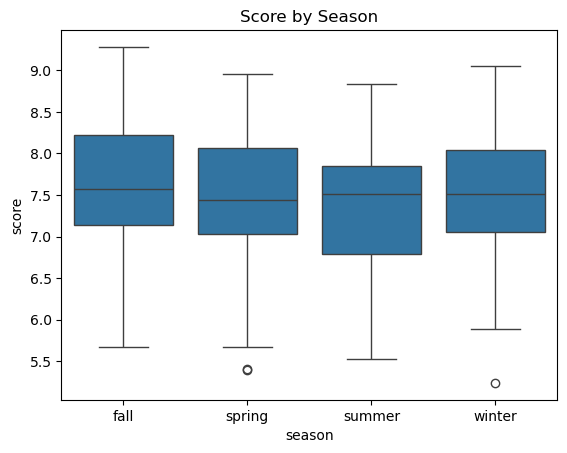

In [10]:
sns.boxplot(x='season',y='score',data=df)
plt.title('Score by Season')
plt.show()

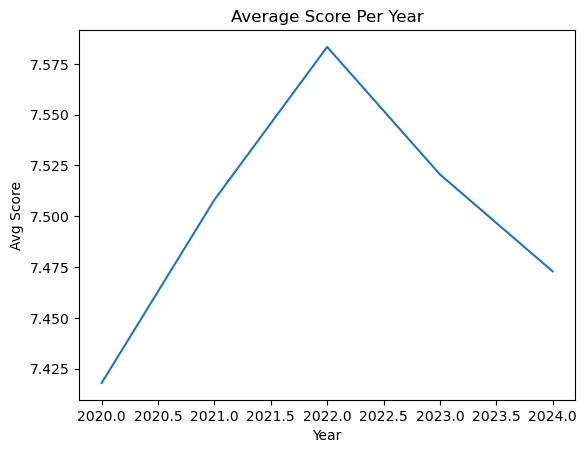

In [11]:
avg_by_year = df.groupby('year')['score'].mean()
plt.plot(avg_by_year.index, avg_by_year.values)
plt.title('Average Score Per Year')
plt.xlabel('Year')
plt.ylabel('Avg Score')
plt.show()

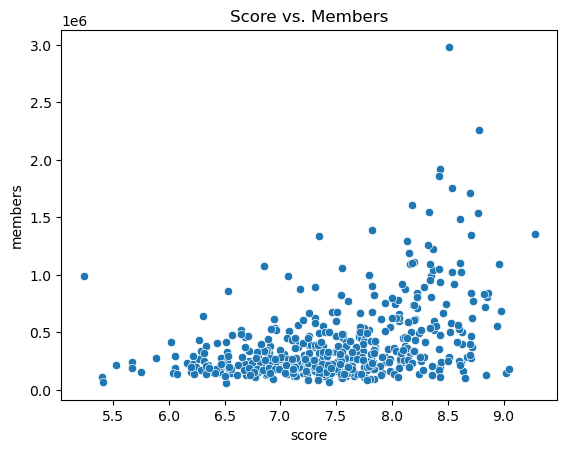

In [12]:
sns.scatterplot(x='score',y='members',data=df)
plt.title('Score vs. Members')
plt.show()

In [13]:
numeric_df = df[['score','members','favorites','episodes']]
print(numeric_df.corr())

              score   members  favorites  episodes
score      1.000000  0.415442   0.452548 -0.032485
members    0.415442  1.000000   0.820371  0.115914
favorites  0.452548  0.820371   1.000000  0.153609
episodes  -0.032485  0.115914   0.153609  1.000000


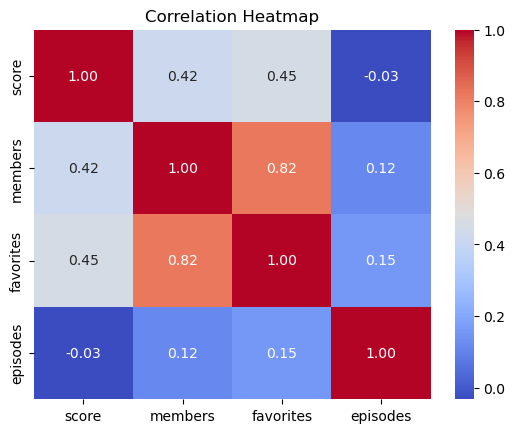

In [14]:
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
#Normality test
stat, p = stats.shapiro(df['score'])
print(f'Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}')
#score isn't normally distributed bc p>0.05

Shapiro-Wilk: stat=0.9929, p=0.0183


In [16]:
#T-test: fall vs spring scores
fall = df[df['season'] == 'fall']['score']
spring = df[df['season'] == 'spring']['score']

t, p = stats.ttest_ind(fall, spring)
print(f'Fall mean: {fall.mean():.2f}, Spring mean: {spring.mean():.2f}')
print(f'T-test: t={t:.4f}, p={p:.4f}')
#no significant difference between fall and spring bc p>0.05

Fall mean: 7.63, Spring mean: 7.47
T-test: t=1.8416, p=0.0667


In [17]:
#Pearson correlation: score vs members
corr, p = stats.pearsonr(df['score'], df['members'])
print(f'Pearson r={corr:.4f}, p={p:.4f}')
#significant correlation between score and members bc p<0.05


Pearson r=0.4154, p=0.0000


In [18]:
#top 10 by score
df[['title', 'score', 'year']].nlargest(10, 'score')

,title,score,year
75,Sousou no Frieren,9.28,2023
424,Gintama: The Final,9.05,2021
114,One Piece Fan Letter,9.02,2024
57,Bleach: Sennen Kessen-hen,8.98,2022
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,2022
157,Fruits Basket: The Final,8.94,2021
450,Shingeki no Kyojin: The Final Season - Kankets...,8.86,2023
76,Kusuriya no Hitorigoto,8.85,2023
142,Kingdom 3rd Season,8.84,2020
257,Violet Evergarden Movie,8.83,2020


In [19]:
#top 10 by members
df[['title', 'members', 'year']].nlargest(10, 'members')

,title,members,year
0,Jujutsu Kaisen,2983273,2020
400,Shingeki no Kyojin: The Final Season,2260937,2021
50,Chainsaw Man,1922428,2022
175,Spy x Family,1862244,2022
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,1756871,2020
425,Kimetsu no Yaiba: Yuukaku-hen,1715034,2022
401,Horimiya,1612067,2021
402,Mushoku Tensei: Isekai Ittara Honki Dasu,1550453,2021
426,Shingeki no Kyojin: The Final Season Part 2,1535035,2022
125,Kaguya-sama wa Kokurasetai? Tensai-tachi no Re...,1485556,2020
